# From Straight Lines to Curves ➰ 

So far, our model has been a simple straight line:

$$
y = a_0 + a_1 x
$$

It did a lovely job on the hardness-versus-strength data, because that relationship really is roughly a straight line. But out in the wild, data loves to *curve*. 

<img src="images/lec03_polynomials.png" width="400">


So how do we let our model bend? We give it some curves to work with. 

$\rightarrow$ Enter **polynomial regression**. 🎢

## Polynomial Regression

The idea is delightfully simple: we keep our straight-line equation and just add on higher powers of $x$.

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \dots + a_n x^n
$$

or, written compactly:

$$
y = \sum_{i=0}^{n} a_i \, x^i
$$

Each new term hands the curve extra freedom to bend. Add an $x^2$ term and it can form a single gentle hump or valley; add $x^3$ and it can wiggle up-then-down; keep going and it can trace increasingly wavy shapes to hug your data. That's exactly what those coloured example curves are doing - same equation, just different numbers of terms and different coefficients producing humps, waves, and swoops.

```{admonition} The big secret 🤫
:class: tip
But here's the thing: **polynomial regression is still linear regression!**

Wait, what? It's full of x2 and x3 terms - how is that linear?

The trick is *what* we're being linear in. The model is linear in its **coefficients** (a0,a1,a2,…), even though it's curvy in x. And the coefficients are the things we're actually solving for. So from the model's point of view, x2 and x3 are just... more input columns. We treat "x", "x squared", "x cubed" as separate features, and fit a good old linear model on top of them.

That means we get to reuse *everything* we already learned - no new fitting method required. Sneaky, right?
```

## Degree of a Polynomial 🍉

The **degree** of a polynomial is simply its highest power of $x$. That single number tells you how flexible the curve is allowed to be:

- $y = a_0 + a_1 x$ &nbsp;→&nbsp; degree **1** (our familiar straight line)
- $y = a_0 + a_1 x + a_2 x^2$ &nbsp;→&nbsp; degree **2** (one bend — a parabola)
- $y = a_0 + a_1 x + a_2 x^2 + a_3 x^3$ &nbsp;→&nbsp; degree **3** (room for two bends)

The pattern keeps going. A degree-5 polynomial, for example, *can* include the terms

$$
x^5,\ x^4,\ x^3,\ x^2,\ x,\ a_0 \ (\text{the constant})
$$

The numerical values sitting in front of each term - the $a_i$'s - are called the **coefficients** of the polynomial. They're the knobs the model turns to shape the curve, and they're precisely what our fitting step will figure out for us.

```{admonition} A tiny gotcha with degree
:class: note
The degree is set by the *highest power that's actually present*, i.e. whose coefficient isn't zero. For instance:

$$
y = 3 + \tfrac{5}{2}x + 21x^2 - 11x^3 + 0\,x^4 + 1\,x^5 \;\;\longrightarrow\;\; y = 3 + \tfrac{5}{2}x + 21x^2 - 11x^3 + 1\,x^5
$$

The x4 term quietly vanishes because its coefficient is 0 - but the polynomial is still **degree 5**, because that x5 term is alive and well at the top.
```

## Polynomial, Deconstructed into a Matrix 🔢

And all of this connects everything back to the matrix framework. We can rewrite the whole polynomial as a single multiplication of two pieces:

$$
y =
\underbrace{\begin{bmatrix} a_0 & a_1 & a_2 & \cdots & a_n \end{bmatrix}}_{\text{coefficient vector}}
\;
\underbrace{\begin{bmatrix} 1 \ x \ x^2 \ \vdots \ x^n \end{bmatrix}}_{\text{feature vector}}
$$

Read left to right, this just says "multiply each coefficient by its matching power of $x$ and add them all up" - which is exactly our polynomial. But splitting it this way makes something click:

- The **feature vector** on the right is our *engineered features*: we took a single input $x$ and expanded it into $1, x, x^2, \dots, x^n$.
- The **coefficient vector** on the left is the set of numbers we're solving for - same role the slope and intercept played for the straight line, just more of them.

```{admonition} Why this is great news 🎉## Optional
:class: tip

If you went through the optional math on the design matrix and the normal equation from the earlier maths detour, then this is where they pay off.

Stack the feature vector for *every* specimen into rows, and you get a design matrix X - one column for each power of x. Then finding the best coefficients is the **exact same** least-squares problem as before:

$$
\boldsymbol{\beta} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{y}
$$

Straight line, quadratic, degree-5 curve - under the hood it's all the same solve. We only changed what we put *into* X. So learning linear regression well really did buy us polynomial regression for free.
```

## ⚠️A gentle word of caution (for later) 

It's tempting to think "more degree = more flexible = better fit = ", and tuning the degree way up will indeed let the curve thread through nearly every point. But a curve that contorts itself to hit every training point often does a *worse* job on new, unseen data - it starts memorising the noise instead of learning the trend. There's a real sweet spot to find.

```{admonition} Callback: interpolation vs extrapolation
:class: warning
Remember interpolation (predicting *inside* your data range) versus extrapolation (predicting *outside* it)? High-degree polynomials are especially dramatic here - just past the edge of your data, they can shoot off toward the sky or the floor almost immediately. 😬 So the "curve everywhere" superpower comes with a "handle with care" label, particularly near the boundaries.
```

We'll dig into how to pick a sensible degree - and how to spot a model that's over-eager - in a later session. For now, the headline is a happy one: our trusty linear regression stretches effortlessly into curves, and it's the very same idea underneath. 🙌




# 🌱Example Problem
Let's generate some data and fit a polynomial - just for fun!

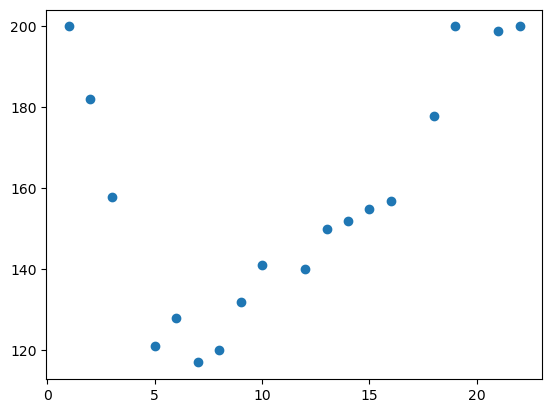

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

x = [1,2,3,5,6,7,8,9,10,12,13,14,15,16,18,19,21,22]   #An array of x values
y = [200,182,158,121,128,117,120,132,141,140,150,152,155,157,178,200,199,200] #An equal number of y values

plt.scatter(x, y)

plt.show()

In [2]:
p = np.polyfit(x, y, 2)  # performs a least-squares polynomial fit on a set of data points. 
        #It calculates the coefficients of a polynomial of a specified degree that best matches the given x and y coordinates
print(p)

[  0.59338395 -11.66941301 189.65528213]


Alternatively you can use

*Polynomial.fit()* function *from numpy.polynomial import Polynomial*

In [3]:
x_new = np.linspace(1, 5, 100)
#print(x_new)

TypeError: 'numpy.ndarray' object is not callable

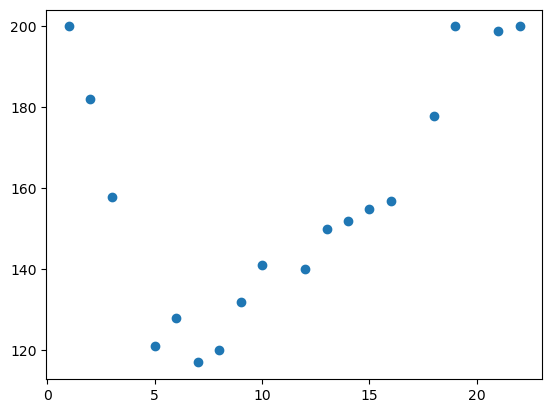

In [4]:
plt.scatter(x, y, label='Data Points')
plt.plot(x_new, p(x_new), 
         label='Fitted Polynomial')
plt.legend()
plt.show()
#This will throw an error - although polyfit() can fit a polynomial to the data, we cannot use it to do computations
#To overcome this we need to use the output generated from the polyfit function and pass it as an argument into another function called poly1d()

Some searching online will make you realize that

np.polyfit(x, y, 3) fits a cubic polynomial to the data in x and y.

np.poly1d(coefficients) creates a callable polynomial object that you can evaluate, plot, differentiate, or integrate.



In [5]:
polymodel2 = np.poly1d(np.polyfit(x, y, 2))
print(polymodel2)

        2
0.5934 x - 11.67 x + 189.7


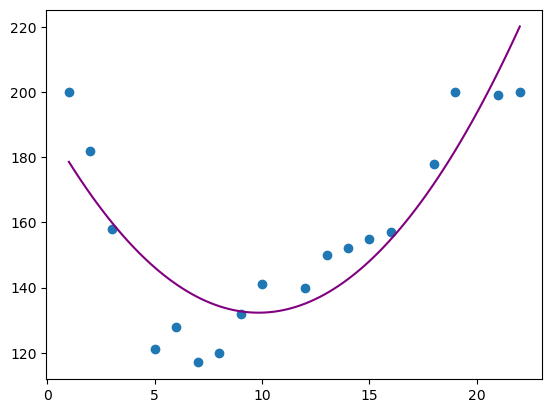

In [6]:
polyline2 = np.linspace(1, 22, 100)
plt.scatter(x, y)
plt.plot(polyline2, 
         polymodel2(polyline2),color='purple')
plt.show()

#The poly1d object represents a polynomial,
#allowing you to treat it like a function 
#that can be evaluated at different points, differentiated, or integrated.

In [7]:
#from sklearn.metrics import r2_score
print(r2_score(y, polymodel2(x)))

0.7800181558191519


          3         2
-0.05469 x + 2.475 x - 29.13 x + 225.3


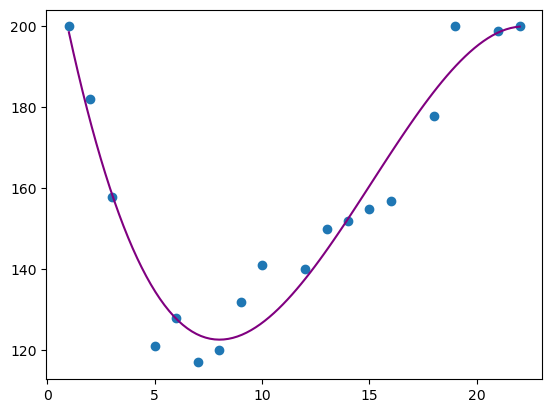

In [8]:
#How to check for 3rd order
polymodel3 = np.poly1d(np.polyfit(x, y, 3))
print(polymodel3)

polyline3 = np.linspace(1, 22, 100)
plt.scatter(x, y)
plt.plot(polyline3,polymodel3(polyline3),color='purple')
plt.show()

In [9]:
print(r2_score(y, polymodel3(x)))

0.9402009882282494


In [10]:
#Instead of computing one by one, let's write a function to do the work
metrics=[]

for deg in range(1,6):
    polymodel = np.poly1d(np.polyfit(x, y, deg))
    r2 = r2_score(y, polymodel(x))
    metrics.append(r2)

print(metrics)



[0.17440827424430416, 0.7800181558191519, 0.9402009882282494, 0.9490893462208017, 0.9553052339803011]


            5           4          3        2
-0.0003893 x + 0.02502 x - 0.6393 x + 8.43 x - 53.61 x + 252.3


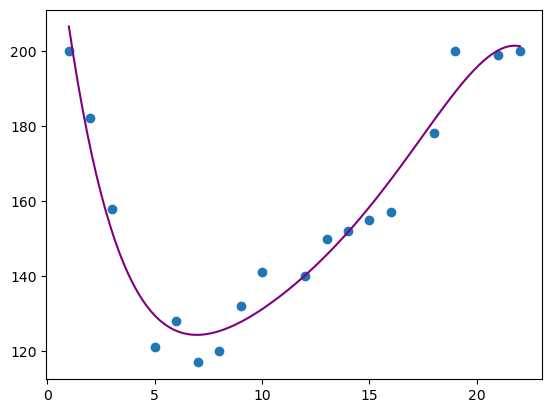

In [11]:
#Best r2 value corresponds to deg = 5
polymodel5 = np.poly1d(np.polyfit(x, y, 5))
print(polymodel5)

polyline5 = np.linspace(1, 22, 100)
plt.scatter(x, y)
plt.plot(polyline5, 
    polymodel5(polyline5),color='purple')
plt.show()

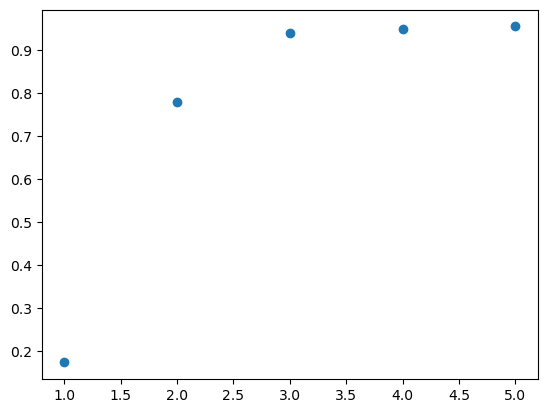

In [12]:
#Let's plot the r2 values

plt.scatter(range(1,6),metrics)
plt.show()

🤔 Notice the marginal improvments with each increase in polynomial order

"Diminishing advantage" - There's a significant improvement going from 1 to 2, and even from 2 to 3. But as we move from 3 to 4, and then 4 to 5..., although there is still an improvement, the rate of improvement is small.

In such cases, we pick our "Optimum" degree as the one that is at the 'elbow' point.

If you pick a polynomial with a even higher degree, you run the risk of "Overfitting" - which we will talk about later.

